Time column is increasing: True
Missing values:
0_x     0
13_x    0
14_x    0
17_x    0
37_x    0
dtype: int64


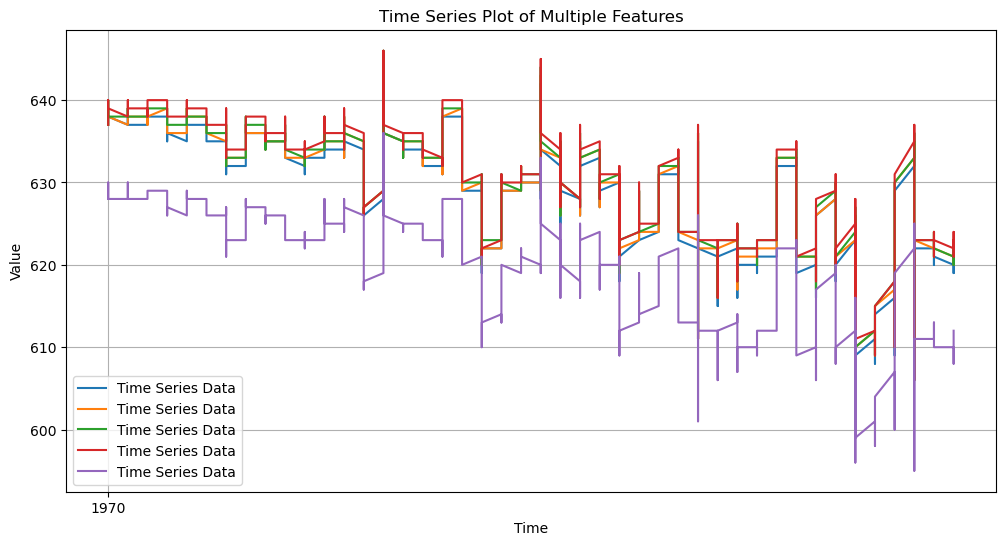

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Veri Setini Yükleme
file_path = "data/selected_lip_coordinates_x_only.csv"
df = pd.read_csv(file_path)
df['time'] = pd.to_datetime(df['time'])
df.set_index("time", inplace=True)
freq = pd.infer_freq(df.index)
if freq is not None:
    df = df.asfreq(freq)

# 2. Zaman Serisi Doğrulama
print("Time column is increasing:", df.index.is_monotonic_increasing)
print("Missing values:")
print(df.isnull().sum())

# 3. Zaman Serisi Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(df, label="Time Series Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series Plot of Multiple Features")
plt.legend()
plt.grid(True)
plt.show()
plt.close()

In [3]:
# 4. ADF Durağanlık Testi ve Durağan Olmayanlara Fark Alma
def adf_test(series):
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    if result[1] <= 0.05:
        print("Seri durağandır.")
        return True
    else:
        print("Seri durağan değildir.")
        return False

print("Durağanlık Testi Sonuçları:")
non_stationary_columns = []
for column in df.columns:
    print(f"\n{column} için ADF Testi:")
    is_stationary = adf_test(df[column])
    if not is_stationary:
        non_stationary_columns.append(column)

Durağanlık Testi Sonuçları:

0_x için ADF Testi:
ADF Statistic: -2.16454425286854
p-value: 0.2193645005987337
Critical Values:
   1%: -3.4364137337554785
   5%: -2.864217382986235
   10%: -2.568195530545688
Seri durağan değildir.

13_x için ADF Testi:
ADF Statistic: -2.20343931721687
p-value: 0.204999552121861
Critical Values:
   1%: -3.436419361753321
   5%: -2.864219865461312
   10%: -2.5681968527091907
Seri durağan değildir.

14_x için ADF Testi:
ADF Statistic: -2.1719662865125042
p-value: 0.21657691926162198
Critical Values:
   1%: -3.4364137337554785
   5%: -2.864217382986235
   10%: -2.568195530545688
Seri durağan değildir.

17_x için ADF Testi:
ADF Statistic: -2.2470378244052447
p-value: 0.18961826581672053
Critical Values:
   1%: -3.4364081161854747
   5%: -2.8642149051061954
   10%: -2.5681942108302214
Seri durağan değildir.

37_x için ADF Testi:
ADF Statistic: -2.1981466674290706
p-value: 0.2069187972105
Critical Values:
   1%: -3.4364081161854747
   5%: -2.8642149051061954
 

In [5]:
# 5. Sadece Durağan Olmayanlara Fark Alma
df_diff = df.copy().astype(np.float32)  # Orijinal veriyi koru ve bellek tüketimini azalt
for column in non_stationary_columns:
    df_diff[column] = df[column].diff()  # Sadece durağan olmayan sütunlara fark alma işlemi uygula
df_diff.dropna(inplace=True)  # İlk fark alınan satırlar NaN olacağı için kaldır

print(f"Durağan olmayan sütunlar: {non_stationary_columns}")

Durağan olmayan sütunlar: ['0_x', '13_x', '14_x', '17_x', '37_x']


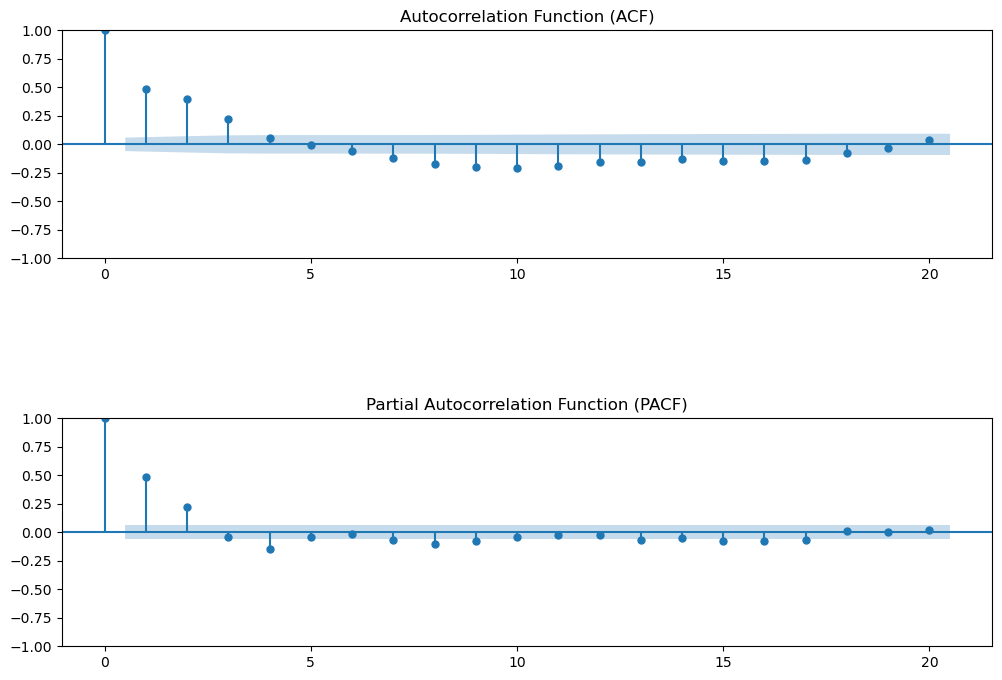

In [7]:
# 6. ACF ve PACF Grafikleri
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_diff.dropna().iloc[:, 0], ax=ax[0], lags=20)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df_diff.dropna().iloc[:, 0], ax=ax[1], lags=20)
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.subplots_adjust(hspace=0.7, wspace=0.4)
plt.show()

In [11]:
# 7. VARMA Modelini Uygulama
df_diff.dropna(inplace=True)  # Modelin veri seti için NaN olmayan verileri kullan
model = VARMAX(df_diff, order=(2, 2), trend='n')
varma_model = model.fit(disp=False)
print(varma_model.summary())

C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      Statespace Model Results                                     
Dep. Variable:     ['0_x', '13_x', '14_x', '17_x', '37_x']   No. Observations:                 1098
Model:                                          VARMA(2,2)   Log Likelihood               -3412.686
Date:                                     Tue, 18 Mar 2025   AIC                           7055.372
Time:                                             12:29:11   BIC                           7630.515
Sample:                                                  0   HQIC                          7272.972
                                                    - 1098                                         
Covariance Type:                                       opg                                         
Ljung-Box (L1) (Q):     0.03, 0.01, 0.01, 0.01, 0.02   Jarque-Bera (JB):   220.24, 40.46, 10.39, 10.23, 5.00
Prob(Q):                0.87, 0.93, 0.91, 0.90, 0.90   Prob(JB):                0.00, 0.00,

In [13]:
# 8. Tahminlerin Görselleştirilmesi
forecast_steps = 10
forecast = varma_model.forecast(steps=forecast_steps)
forecast_df = pd.DataFrame(forecast, columns=df_diff.columns)

C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [15]:
# Orijinal ölçeğe dönüştürme
for column in non_stationary_columns:
    forecast_df[column] = df[column].iloc[-1] + forecast_df[column].cumsum()

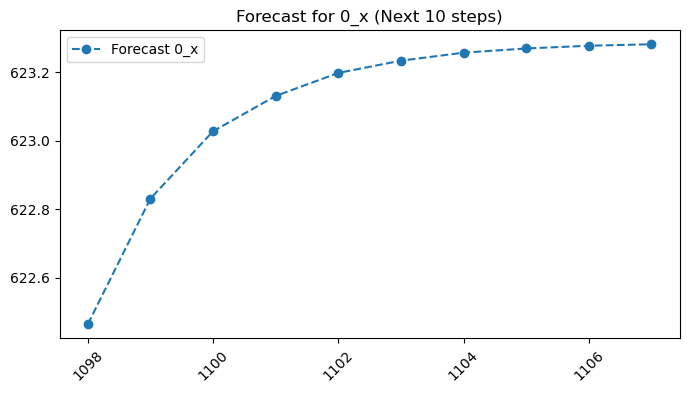

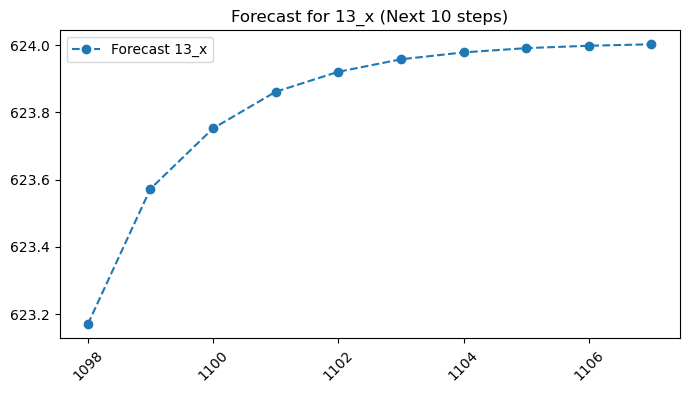

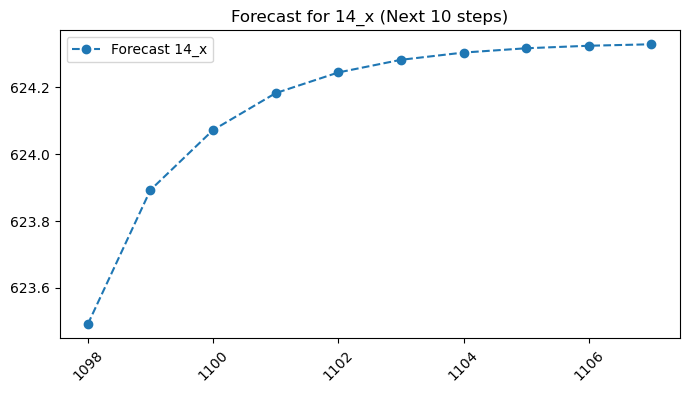

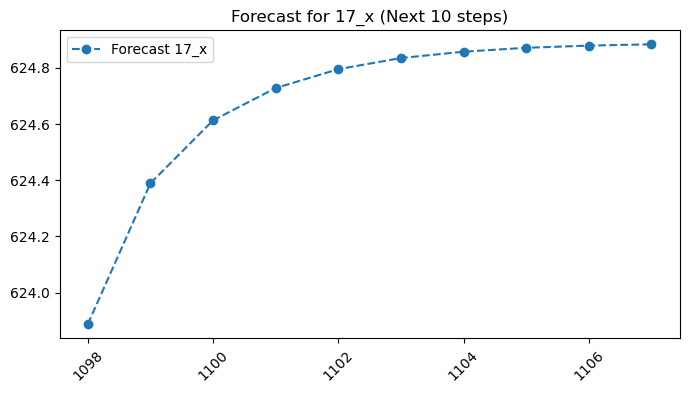

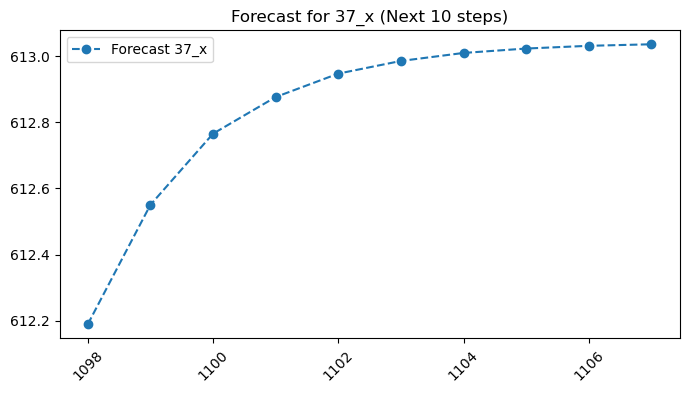

In [17]:
num_columns = len(forecast_df.columns)
cols = 2  # 3 yerine 2 sütun kullanarak daha geniş bir görünüm sağla
rows = int(np.ceil(num_columns / cols))  

for i, column in enumerate(forecast_df.columns[:10]):  # İlk 10 değişkeni göster
    plt.figure(figsize=(8, 4))  
    plt.plot(forecast_df[column], marker='o', linestyle='dashed', label=f'Forecast {column}')
    plt.title(f'Forecast for {column} (Next {forecast_steps} steps)')
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()  # Her grafik için ayrı göster

In [19]:
# 9. Performans Metriklerini Hesaplama
actual_values = df.iloc[-forecast_steps:].copy()
actual_values = actual_values[forecast_df.columns]  # Sütun sırasını tahmin edilenlerle eşitle  # Sütunları tahmin edilenlerle senkronize et
for column in non_stationary_columns:
    actual_values[column] = df[column].iloc[-forecast_steps:].values  # Gerçek fark verileri
predicted_values = forecast_df.values

# Gerçek ve tahmin edilen değerleri yazdırma
print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for i in range(forecast_steps):
    print(f"\nStep {i+1}:")
    for j, column in enumerate(forecast_df.columns):
        print(f"{column} -> Gerçek: {actual_values.iloc[i, j]:.4f}, Tahmin: {predicted_values[i, j]:.4f}")

mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual_values - predicted_values) / np.where(actual_values != 0, actual_values, np.nan))) * 100

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

Gerçek Değerler vs Tahmin Edilen Değerler:

Step 1:
0_x -> Gerçek: 620.0000, Tahmin: 622.4641
13_x -> Gerçek: 621.0000, Tahmin: 623.1695
14_x -> Gerçek: 622.0000, Tahmin: 623.4904
17_x -> Gerçek: 622.0000, Tahmin: 623.8874
37_x -> Gerçek: 610.0000, Tahmin: 612.1892

Step 2:
0_x -> Gerçek: 621.0000, Tahmin: 622.8313
13_x -> Gerçek: 622.0000, Tahmin: 623.5725
14_x -> Gerçek: 622.0000, Tahmin: 623.8926
17_x -> Gerçek: 622.0000, Tahmin: 624.3891
37_x -> Gerçek: 610.0000, Tahmin: 612.5502

Step 3:
0_x -> Gerçek: 621.0000, Tahmin: 623.0280
13_x -> Gerçek: 622.0000, Tahmin: 623.7523
14_x -> Gerçek: 623.0000, Tahmin: 624.0724
17_x -> Gerçek: 623.0000, Tahmin: 624.6131
37_x -> Gerçek: 611.0000, Tahmin: 612.7653

Step 4:
0_x -> Gerçek: 622.0000, Tahmin: 623.1313
13_x -> Gerçek: 623.0000, Tahmin: 623.8613
14_x -> Gerçek: 623.0000, Tahmin: 624.1830
17_x -> Gerçek: 624.0000, Tahmin: 624.7280
37_x -> Gerçek: 612.0000, Tahmin: 612.8761

Step 5:
0_x -> Gerçek: 622.0000, Tahmin: 623.1986
13_x -> Gerçek